In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

1. Import the dataframe (overview)
2. Data cleaning
3. EDA (Exploratory Data Anylysis) 
4. Preprocessing 
5. Split and train data (80/20)
6. Train and evaluate 
7. Advance: test, fine-tuning, deploy....

In [83]:
df = pd.read_csv('heart.csv') #import data
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [84]:
df.info() # 1061 rows, 12 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1061 non-null   int64  
 1   Sex             1061 non-null   object 
 2   ChestPainType   1061 non-null   object 
 3   RestingBP       1061 non-null   int64  
 4   Cholesterol     1061 non-null   int64  
 5   FastingBS       1061 non-null   int64  
 6   RestingECG      1061 non-null   object 
 7   MaxHR           1061 non-null   int64  
 8   ExerciseAngina  1061 non-null   object 
 9   Oldpeak         1061 non-null   float64
 10  ST_Slope        1061 non-null   object 
 11  HeartDisease    1061 non-null   int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 99.6+ KB


In [85]:
df.describe() # RestingBP and Cholesterol are unsual

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000,1061.000000
mean,53.691800,132.421301,202.864279,0.221489,137.774741,0.900848,0.555137
std,9.365846,18.072879,105.159468,0.415445,25.285412,1.097961,0.497185
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,177.000000,0.000000,120.000000,0.000000,0.000000
50%,55.000000,130.000000,222.000000,0.000000,140.000000,0.500000,1.000000
75%,60.000000,140.000000,265.000000,0.000000,157.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [86]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
1056,62,M,ATA,120,254,0,LVH,93,Y,0.0,Flat,1
1057,70,M,ASY,130,322,0,LVH,109,N,2.4,Flat,1
1058,67,F,NAP,115,564,0,LVH,160,N,1.6,Flat,0
1059,57,M,ATA,124,261,0,Normal,141,N,0.3,Up,1
1060,64,M,ASY,128,263,0,Normal,105,Y,0.2,Flat,0


In [87]:
df.isnull().sum() # no empty cell

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [88]:
df = df.drop_duplicates() # remove duplicates if any

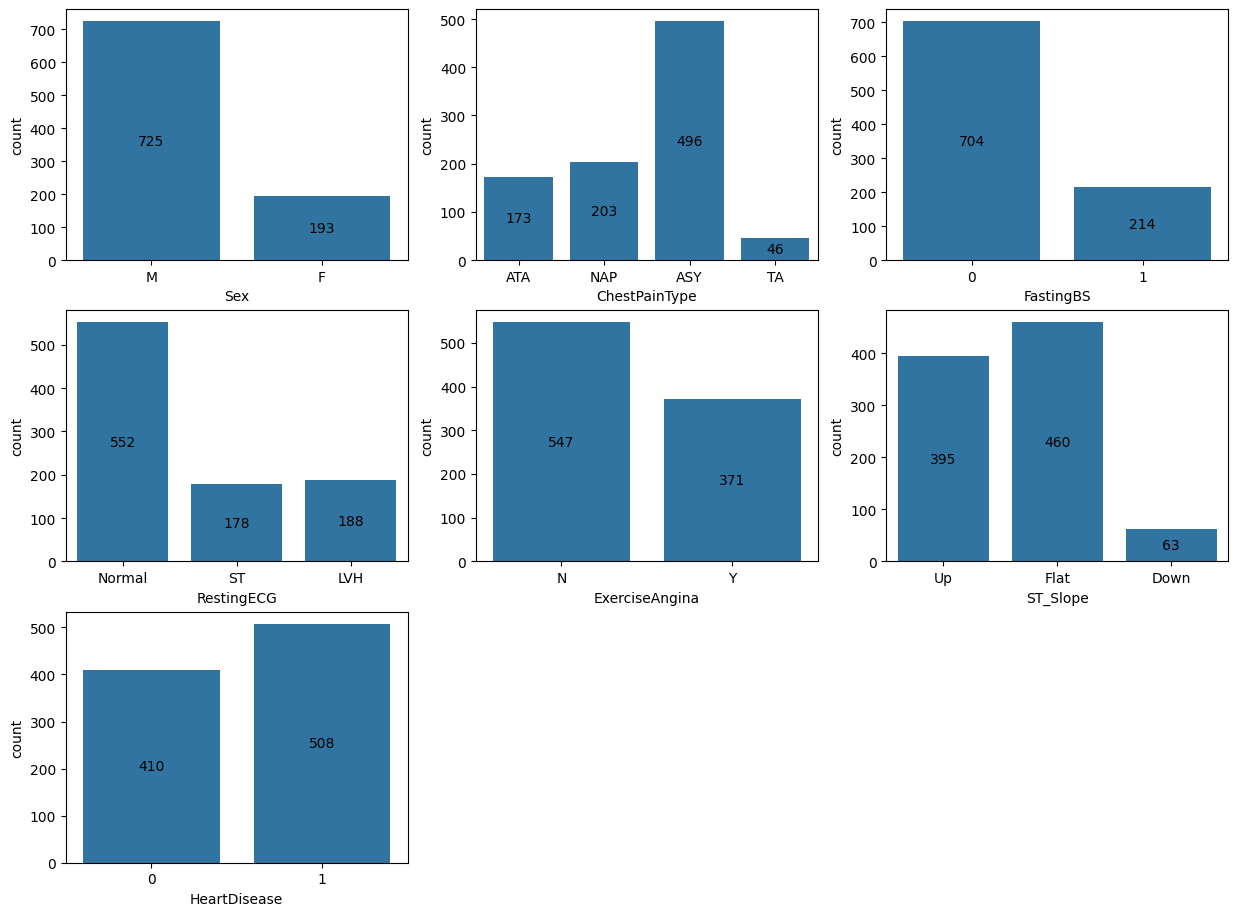

In [89]:
categorical = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease'] # divide data type into numeric or categorical

fig = plt.figure(figsize=(15,15)) # create bar chart to visualize the categories count

for index, column in enumerate(categorical):
    ax = plt.subplot(4,3,index + 1)
    sns.countplot(x=df[column], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type='center')

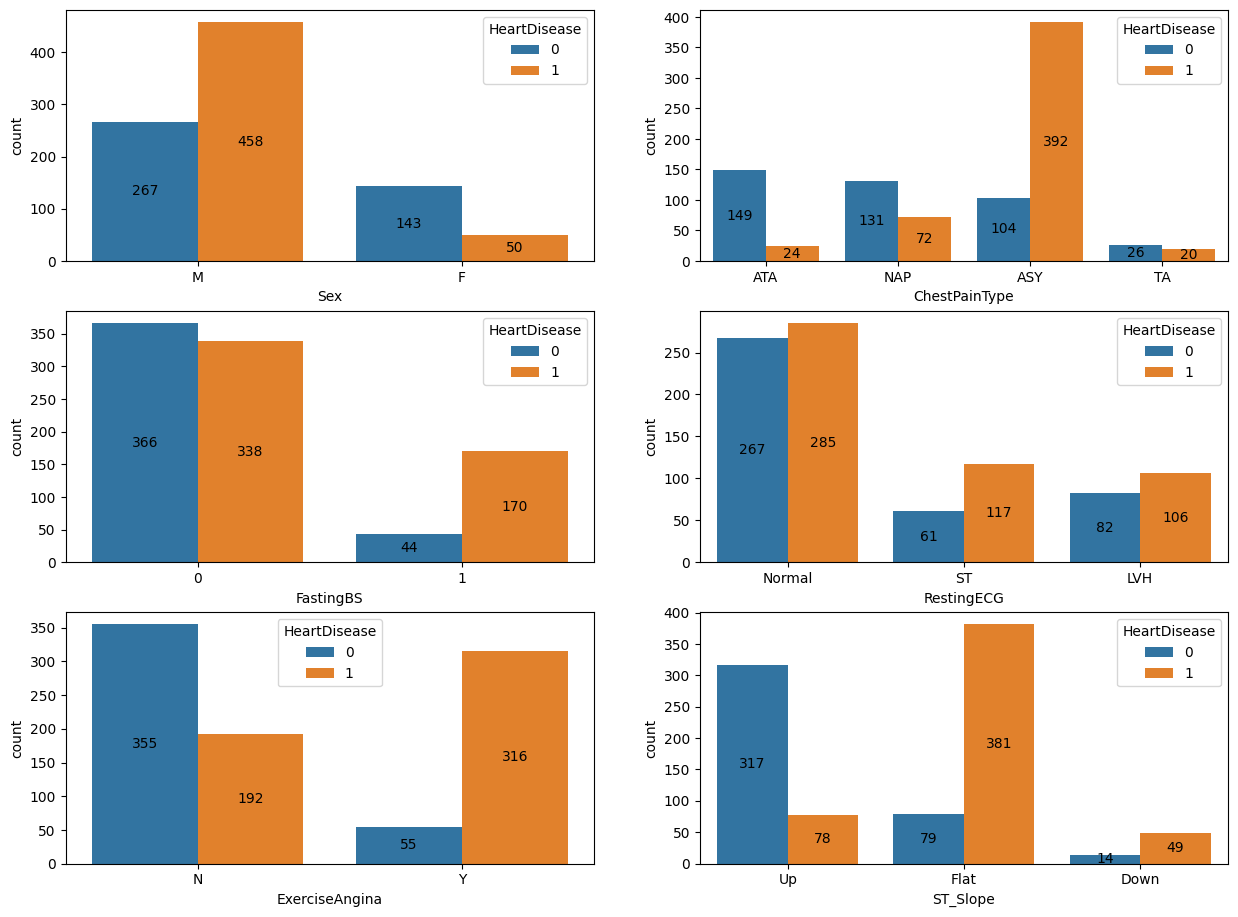

In [90]:
fig =plt.figure(figsize=(15,15)) # compare heartdisease and non heartdisease side by side

for index, column in enumerate(categorical[:-1]):
    ax= plt.subplot(4, 2, index +1)
    sns.countplot(x=df[column], hue=df['HeartDisease'], ax=ax)
    for container in ax.containers:
        ax.bar_label(container, label_type='center')

In [91]:
df[df['RestingBP']==0].info() # check abnormal value (= 0)

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 449 to 449
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1 non-null      int64  
 1   Sex             1 non-null      object 
 2   ChestPainType   1 non-null      object 
 3   RestingBP       1 non-null      int64  
 4   Cholesterol     1 non-null      int64  
 5   FastingBS       1 non-null      int64  
 6   RestingECG      1 non-null      object 
 7   MaxHR           1 non-null      int64  
 8   ExerciseAngina  1 non-null      object 
 9   Oldpeak         1 non-null      float64
 10  ST_Slope        1 non-null      object 
 11  HeartDisease    1 non-null      int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 104.0+ bytes


In [92]:
df[df['Cholesterol']==0].info() # check abnormal value (= 0)

<class 'pandas.core.frame.DataFrame'>
Index: 172 entries, 293 to 536
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             172 non-null    int64  
 1   Sex             172 non-null    object 
 2   ChestPainType   172 non-null    object 
 3   RestingBP       172 non-null    int64  
 4   Cholesterol     172 non-null    int64  
 5   FastingBS       172 non-null    int64  
 6   RestingECG      172 non-null    object 
 7   MaxHR           172 non-null    int64  
 8   ExerciseAngina  172 non-null    object 
 9   Oldpeak         172 non-null    float64
 10  ST_Slope        172 non-null    object 
 11  HeartDisease    172 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 17.5+ KB


In [93]:
df_clean = df.copy() # replace it with mean value according to heartdisease and non-heartdisease

df_clean = df_clean[df_clean['RestingBP'] != 0]

heartdisease_mask = df_clean['HeartDisease'] == 0

cholesterol_without_heartdisease = df_clean.loc[heartdisease_mask, 'Cholesterol']
cholesterol_with_heartdisease = df_clean.loc[~heartdisease_mask, 'Cholesterol'] 

df_clean.loc[heartdisease_mask, 'Cholesterol'] = cholesterol_without_heartdisease.replace(to_replace = 0, value = cholesterol_without_heartdisease.median())
df_clean.loc[~heartdisease_mask, 'Cholesterol'] = cholesterol_with_heartdisease.replace(to_replace = 0, value = cholesterol_with_heartdisease.median())

In [94]:
df_clean[['Cholesterol', 'RestingBP']].describe() # check the min value again

,Cholesterol,RestingBP
count,917.000000,917.000000
mean,239.700109,132.540894
std,54.352727,17.999749
min,85.000000,80.000000
25%,214.000000,120.000000
50%,225.000000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


In [95]:
df_clean = pd.get_dummies(df_clean, drop_first=True) # transform categorical value into boolean
df_clean.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


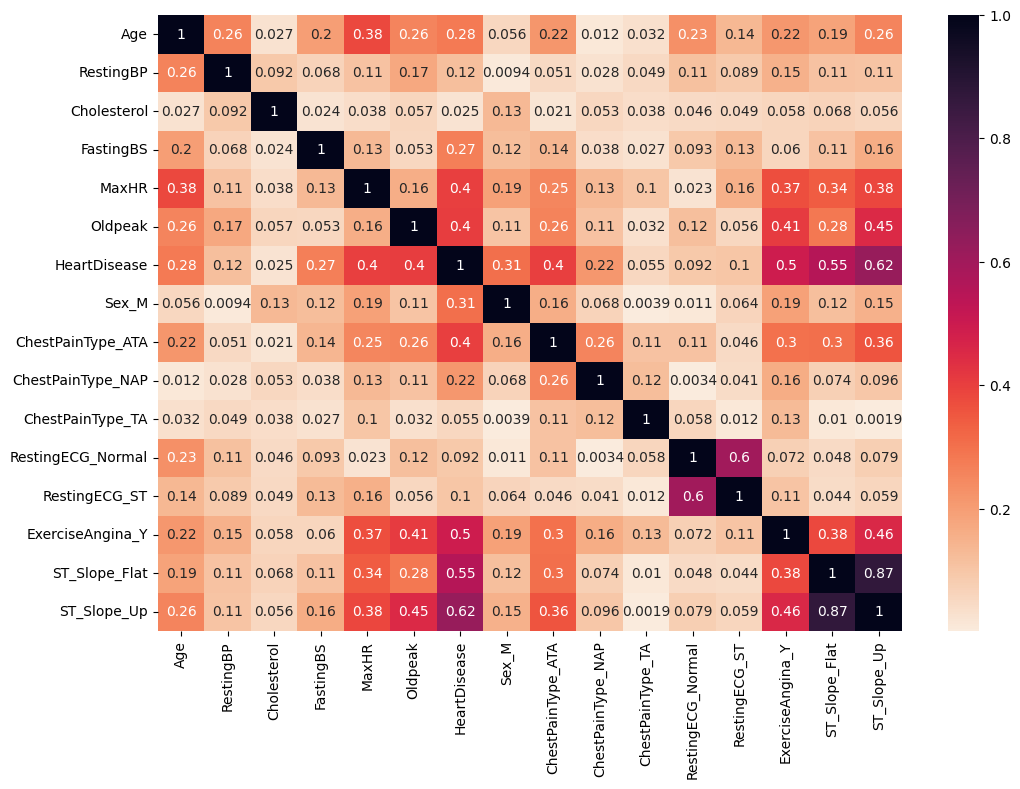

In [96]:
correlations = abs(df_clean.corr()) # check the relationship between them
plt.figure(figsize=(12,8))
sns.heatmap(correlations, annot=True, cmap='rocket_r')
plt.show()

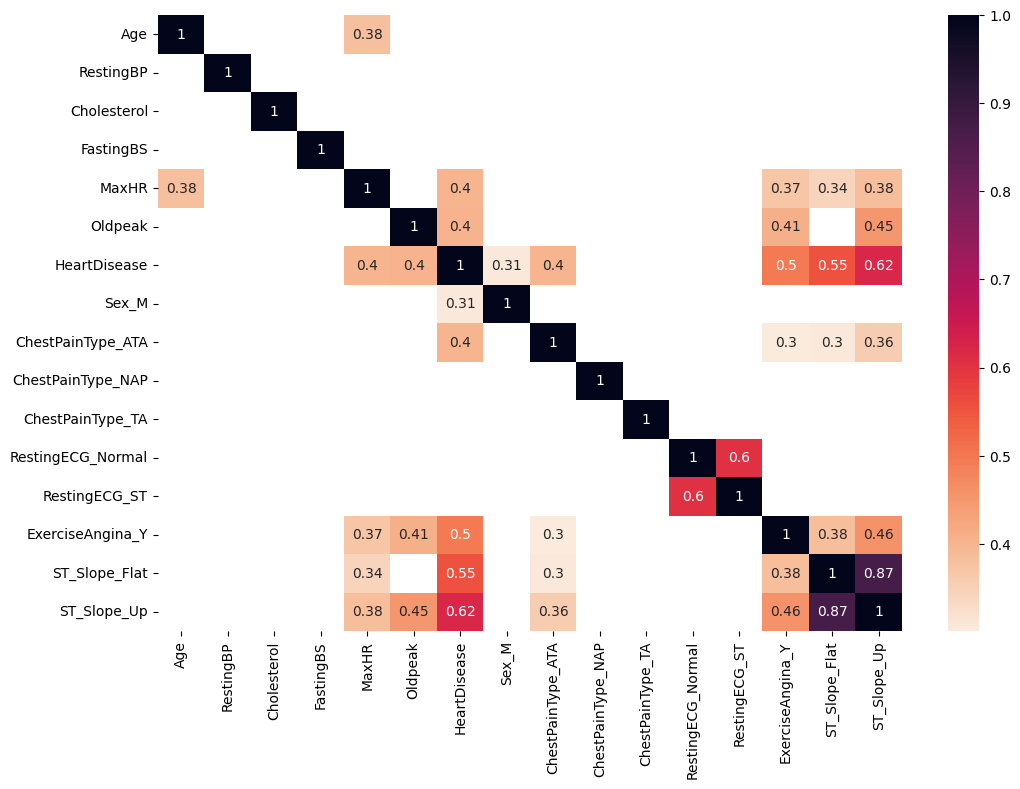

In [97]:
plt.figure(figsize=(12,8)) # filter the most important feature for traning data
sns.heatmap(correlations[correlations>0.3], annot=True, cmap='rocket_r')
plt.show()

In [98]:
# splitting data
X = df_clean.drop(['HeartDisease'], axis=1)
y = df_clean['HeartDisease']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state= 417)

In [99]:
# train data by each feature

features = ['MaxHR','Oldpeak', 'Sex_M', 'ExerciseAngina_Y', "ST_Slope_Flat", 'ST_Slope_Up']

for feature in features:
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train[[feature]], y_train)
    accuracy = knn.score(X_val[[feature]], y_val)
    print(f'The k-NN classifier trained on {feature} and with k = 3 has an accuracy of {accuracy*100:.2f}%')

The k-NN classifier trained on MaxHR and with k = 3 has an accuracy of 61.41%
The k-NN classifier trained on Oldpeak and with k = 3 has an accuracy of 69.57%
The k-NN classifier trained on Sex_M and with k = 3 has an accuracy of 55.98%
The k-NN classifier trained on ExerciseAngina_Y and with k = 3 has an accuracy of 71.20%
The k-NN classifier trained on ST_Slope_Flat and with k = 3 has an accuracy of 78.26%
The k-NN classifier trained on ST_Slope_Up and with k = 3 has an accuracy of 80.98%


In [100]:
# train data by all features

scaler = MinMaxScaler() # transform numerical data into a fix range so the model will treat them equally
X_train_scaled = scaler.fit_transform(X_train[features])
X_val_scaled = scaler.transform(X_val[features])

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
accuracy = knn.score(X_val_scaled, y_val)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 80.98%


In [101]:
# Train with some of the features removed

X = df_clean.drop(["HeartDisease"], axis=1)
y = df_clean['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=417)

features = ['MaxHR', 
            'Oldpeak', 
            'ExerciseAngina_Y',
            #'Sex_M', 
            "ST_Slope_Flat", 
            "ST_Slope_Up"]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[features])
X_train_scaled

array([[0.63380282, 0.36585366, 0.        , 1.        , 0.        ],
       [0.45774648, 0.43902439, 1.        , 1.        , 0.        ],
       [0.66901408, 0.31707317, 0.        , 0.        , 1.        ],
       ...,
       [0.26056338, 0.51219512, 1.        , 0.        , 1.        ],
       [0.15492958, 0.19512195, 0.        , 0.        , 1.        ],
       [0.59859155, 0.63414634, 0.        , 1.        , 0.        ]])

In [102]:
grid_params = {"n_neighbors": range(1,20),
               "metric": ['minkowski', 'manhattan']}

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, grid_params, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train);
knn_grid.best_score_*100, knn_grid.best_params_

(np.float64(83.21218898518312), {'metric': 'manhattan', 'n_neighbors': 18})

In [103]:
X_test_scaled = scaler.transform(X_test[features])
predictions = knn_grid.best_estimator_.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print(f"Model accuracy on test: {accuracy*100:.2f}%")

Model accuracy on test: 81.52%


In [104]:
# check data distribution
print("Distribution of patients by their sex in the entire dataset")
print(X.Sex_M.value_counts()) 

Distribution of patients by their sex in the entire dataset
Sex_M
True     724
False    193
Name: count, dtype: int64


In [105]:
print("Distribution of patients by their sex int the training dataset")
print(X_train.Sex_M.value_counts())

Distribution of patients by their sex int the training dataset
Sex_M
True     580
False    153
Name: count, dtype: int64


In [106]:
print('Distribution of patients by their sex in the test dataset')  
print(X_test.Sex_M.value_counts())

Distribution of patients by their sex in the test dataset
Sex_M
True     144
False     40
Name: count, dtype: int64


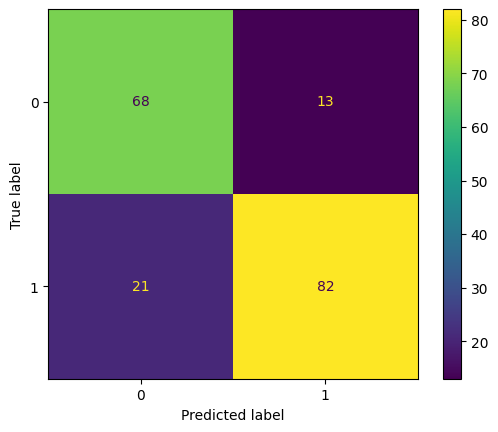

In [107]:
cf = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cf).plot()
plt.show()

In [108]:
from xgboost import XGBClassifier

X = df_clean.drop(["HeartDisease"], axis=1)
y = df_clean['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=417)

model = XGBClassifier()

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [109]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 84.78%


In [110]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        81
           1       0.86      0.86      0.86       103

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



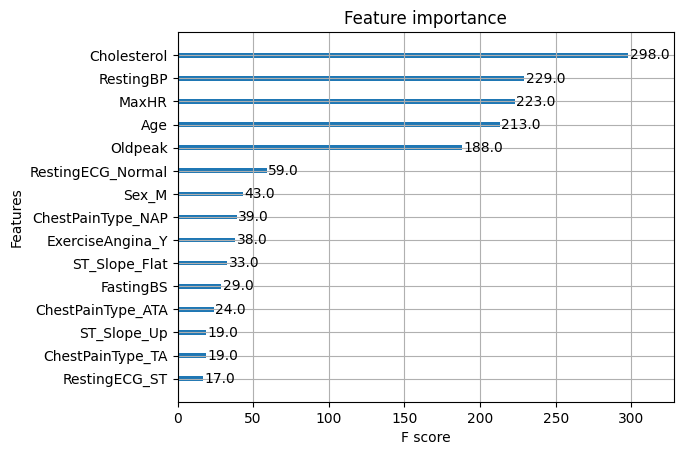

In [111]:
from xgboost import plot_importance

plot_importance(model)

plt.show()

In [112]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [113]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 86.41%
